# Creating a baseline model

In [1]:
import os
import numpy as np
import pandas as pd
import librosa

import matplotlib.pyplot as plt

from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## Loading the data

Demographic data

In [2]:
path = "/Users/keira/code/mi-mi-mia/smart-stethoscope/raw_data/demographic_info.txt"

demographic_data = pd.read_csv(path, sep=' ', header=None)

demographic_data.columns = [
    "patient_id",
    "age",
    "sex",
    "adult_bmi",
    "child_weight",
    "child_height"
]

demographic_data.head()

,patient_id,age,sex,adult_bmi,child_weight,child_height
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0


In [3]:
demographic_data.isna().sum()

patient_id       0
age              1
sex              1
adult_bmi       51
child_weight    82
child_height    84
dtype: int64

Diagnosis data

In [4]:
diagnosis_path = "/Users/keira/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv"

diagnosis_df = pd.read_csv(diagnosis_path)

diagnosis_df.columns = [
    "patient_id",
    "disease"
]

diagnosis_df.head()

,patient_id,disease
0,102,Healthy
1,103,Asthma
2,104,COPD
3,105,URTI
4,106,COPD


In [ ]:
diagnosis_df.isna().sum()

patient_id    0
disease       0
dtype: int64

Audio files and annotation

In [6]:
audio_annot_path = "/Users/keira/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"

files = os.listdir(audio_annot_path)

audio_files = [f for f in files if f.endswith(".wav")]

audio_df = pd.DataFrame(audio_files, columns=["file_name"])

audio_df.head()

,file_name
0,122_2b1_Tc_mc_LittC2SE.wav
1,113_1b1_Lr_sc_Litt3200.wav
2,178_1b3_Pl_mc_AKGC417L.wav
3,220_1b1_Tc_mc_LittC2SE.wav
4,176_1b3_Tc_mc_AKGC417L.wav


In [8]:
annotation_files = [f for f in files if f.endswith(".txt")]

annotation_df = pd.DataFrame(annotation_files)

annotation_df.head()


,0
0,148_1b1_Al_sc_Meditron.txt
1,130_3p2_Tc_mc_AKGC417L.txt
2,107_2b4_Al_mc_AKGC417L.txt
3,160_2b4_Pr_mc_AKGC417L.txt
4,174_1p4_Ar_mc_AKGC417L.txt


In [10]:
len(demographic_data), len(diagnosis_df), len(audio_df), len(annotation_df)

(126, 125, 920, 920)

Extract data from file names

In [11]:
# remove .wav
audio_df["file_name_no_ext"] = audio_df["file_name"].str.replace(".wav", "", regex=False)

# split by underscore
audio_df["split"] = audio_df["file_name_no_ext"].str.split("_")

# create new columns from splits
audio_df["patient_id"] = audio_df["split"].str[0]
audio_df["recording_index"] = audio_df["split"].str[1]
audio_df["chest_location"] = audio_df["split"].str[2]
audio_df["acquisition_mode"] = audio_df["split"].str[3]
audio_df["equipment"] = audio_df["split"].str[4]

# tidy up helper columns
audio_df = audio_df.drop(columns=["file_name_no_ext", "split"])

audio_df.head()

,file_name,patient_id,recording_index,chest_location,acquisition_mode,equipment
0,122_2b1_Tc_mc_LittC2SE.wav,122,2b1,Tc,mc,LittC2SE
1,113_1b1_Lr_sc_Litt3200.wav,113,1b1,Lr,sc,Litt3200
2,178_1b3_Pl_mc_AKGC417L.wav,178,1b3,Pl,mc,AKGC417L
3,220_1b1_Tc_mc_LittC2SE.wav,220,1b1,Tc,mc,LittC2SE
4,176_1b3_Tc_mc_AKGC417L.wav,176,1b3,Tc,mc,AKGC417L


## Merge dataframes

In [12]:
# Ensure patient ID same data type across dataframes
diagnosis_df["patient_id"] = diagnosis_df["patient_id"].astype(int)
audio_df["patient_id"] = audio_df["patient_id"].astype(int)
demographic_data["patient_id"] = demographic_data["patient_id"].astype(int)

# Merge dataframes (must contain patient_id column)
df_base = audio_df.merge(diagnosis_df, on="patient_id", how="left")
df_base = df_base.merge(demographic_data, on="patient_id", how="left")

df_base.head()

,file_name,patient_id,recording_index,chest_location,acquisition_mode,equipment,disease,age,sex,adult_bmi,child_weight,child_height
0,122_2b1_Tc_mc_LittC2SE.wav,122,2b1,Tc,mc,LittC2SE,Pneumonia,66.0,M,33.00,NaN,NaN
1,113_1b1_Lr_sc_Litt3200.wav,113,1b1,Lr,sc,Litt3200,COPD,58.0,M,28.41,NaN,NaN
2,178_1b3_Pl_mc_AKGC417L.wav,178,1b3,Pl,mc,AKGC417L,COPD,58.0,M,30.10,NaN,NaN
3,220_1b1_Tc_mc_LittC2SE.wav,220,1b1,Tc,mc,LittC2SE,COPD,66.0,M,35.40,NaN,NaN
4,176_1b3_Tc_mc_AKGC417L.wav,176,1b3,Tc,mc,AKGC417L,COPD,65.0,M,30.10,NaN,NaN


In [13]:
# Remove columns we don't need

df_base = df_base.drop(columns=["recording_index", "acquisition_mode", "equipment"])

df_base.head()

,file_name,patient_id,chest_location,disease,age,sex,adult_bmi,child_weight,child_height
0,122_2b1_Tc_mc_LittC2SE.wav,122,Tc,Pneumonia,66.0,M,33.00,NaN,NaN
1,113_1b1_Lr_sc_Litt3200.wav,113,Lr,COPD,58.0,M,28.41,NaN,NaN
2,178_1b3_Pl_mc_AKGC417L.wav,178,Pl,COPD,58.0,M,30.10,NaN,NaN
3,220_1b1_Tc_mc_LittC2SE.wav,220,Tc,COPD,66.0,M,35.40,NaN,NaN
4,176_1b3_Tc_mc_AKGC417L.wav,176,Tc,COPD,65.0,M,30.10,NaN,NaN


## Clean data

Deal with null values

In [14]:
df_base.isna().sum()

file_name           0
patient_id          0
chest_location      0
disease             2
age                 6
sex                 6
adult_bmi          85
child_weight      851
child_height      853
dtype: int64

In [15]:
# ======================
# AGE: 6 missing values
# ======================
# Fill missing age values with the median age
df_base["age"] = df_base["age"].fillna(df_base["age"].median())


# ======================
# SEX: 6 missing values
# ======================
# Fill missing sex values with "Unknown"
df_base["sex"] = df_base["sex"].fillna("Unknown")

# Encode sex as numbers
df_base["sex"] = LabelEncoder().fit_transform(df_base["sex"])

# Replace encoded "Unknown" value (2) with most common (1)
df_base["sex"] = df_base["sex"].replace(2, 1)

# ======================
# CHEST LOCATION
# ======================
# One-hot encode chest location
df_base = pd.get_dummies(
    df_base,
    columns=["chest_location"],
    drop_first=False
)

# ======================
# DISEASE: 2 missing values
# ======================
df_base = df_base.dropna(subset=["disease"])

In [16]:
df_base.isna().sum()

file_name              0
patient_id             0
disease                0
age                    0
sex                    0
adult_bmi             83
child_weight         851
child_height         853
chest_location_Al      0
chest_location_Ar      0
chest_location_Ll      0
chest_location_Lr      0
chest_location_Pl      0
chest_location_Pr      0
chest_location_Tc      0
dtype: int64

## Calculate normalised BMI for adults and children

In [17]:
# ================================
# BMI Normalisation Function
# ================================
def calculate_bmi(row):
    """
    Calculates a normalised BMI value.
    Adults (>=19): adult_bmi divided by 25.
    Children: BMI normalised by age/sex thresholds.
    Returns np.nan if insufficient data.
    """

    # -------- Adult case --------
    if row['age'] >= 19:
        # If adult_bmi exists, normalise by 25
        return row['adult_bmi'] / 25 if pd.notna(row['adult_bmi']) else np.nan

    # -------- Child case --------
    # Must have weight and height
    if pd.isna(row['child_weight']) or pd.isna(row['child_height']):
        return np.nan

    # Compute raw BMI for child
    raw_bmi = row['child_weight'] / (row['child_height'] / 100) ** 2
    age = row['age']
    sex = row['sex']  # 0 = Male, 1 = Female

    # Special handling for under 2
    if age < 2:
        return raw_bmi / 16.5

    # -------- Male thresholds --------
    elif sex == 0:
        thresholds = [
            (9, 16), (11, 17), (12, 18), (13, 18.6), (14, 19.3),
            (15, 20), (16, 20.6), (17, 21.3), (18, 22), (19, 22.6), (20, 23)
        ]

        for max_age, divisor in thresholds:
            if age <= max_age:
                return raw_bmi / divisor

    # -------- Female thresholds --------
    elif sex == 1:
        thresholds = [
            (9, 16), (11, 17.5), (12, 18), (13, 18.6), (14, 19.3),
            (15, 20), (16, 20.5), (17, 20.8), (18, 21.2), (19, 21.5), (20, 21.8)
        ]

        for max_age, divisor in thresholds:
            if age <= max_age:
                return raw_bmi / divisor

    # If nothing matched
    return np.nan

In [18]:
# ================================
# Apply function row-wise
# ================================
df_base['bmi'] = df_base.apply(calculate_bmi, axis=1)

df_base['bmi'].describe()

count    900.000000
mean       1.040509
std        0.203369
min        0.660000
25%        0.904000
50%        1.056000
75%        1.162800
max        2.140000
Name: bmi, dtype: float64

In [19]:
# drop original weight, height, bmi data
df_base = df_base.drop(columns=["adult_bmi", "child_weight", "child_height"])

In [20]:
df_base.columns

Index(['file_name', 'patient_id', 'disease', 'age', 'sex', 'chest_location_Al',
       'chest_location_Ar', 'chest_location_Ll', 'chest_location_Lr',
       'chest_location_Pl', 'chest_location_Pr', 'chest_location_Tc', 'bmi'],
      dtype='object')

## Add annotation data

In [21]:
def summarise_annotation(file_name):
    """
    Given a .wav file name (e.g. 122_2b1_Tc_mc_LittC2SE.wav),
    load the matching .txt annotation file
    and return:
    - has_crackles (0 or 1)
    - has_wheezes (0 or 1)
    """

    # Replace .wav with .txt
    txt_file = file_name.replace(".wav", ".txt")

    # Build full path to annotation file
    full_path = os.path.join(audio_annot_path, txt_file)

    # Read annotation file (tab separated, no header)
    annotation = pd.read_csv(full_path, sep="\t", header=None)

    # Assign clear column names
    annotation.columns = ["start", "end", "crackles", "wheezes"]

    # If any cycle has crackles = 1 → recording has crackles
    has_crackles = annotation["crackles"].max()

    # If any cycle has wheezes = 1 → recording has wheezes
    has_wheezes = annotation["wheezes"].max()

    return has_crackles, has_wheezes

# Create empty lists to store results
crackles_list = []
wheezes_list = []

# Loop through every recording in merged_df
for file_name in df_base["file_name"]:

    has_crackles, has_wheezes = summarise_annotation(file_name)

    crackles_list.append(has_crackles)
    wheezes_list.append(has_wheezes)

# Add new columns to dataframe
df_base["has_crackles"] = crackles_list
df_base["has_wheezes"] = wheezes_list

# Check result
df_base.head()

,file_name,patient_id,disease,age,sex,chest_location_Al,chest_location_Ar,chest_location_Ll,chest_location_Lr,chest_location_Pl,chest_location_Pr,chest_location_Tc,bmi,has_crackles,has_wheezes
0,122_2b1_Tc_mc_LittC2SE.wav,122,Pneumonia,66.0,1,False,False,False,False,False,False,True,1.3200,0,1
1,113_1b1_Lr_sc_Litt3200.wav,113,COPD,58.0,1,False,False,False,True,False,False,False,1.1364,0,0
2,178_1b3_Pl_mc_AKGC417L.wav,178,COPD,58.0,1,False,False,False,False,True,False,False,1.2040,0,0
3,220_1b1_Tc_mc_LittC2SE.wav,220,COPD,66.0,1,False,False,False,False,False,False,True,1.4160,1,0
4,176_1b3_Tc_mc_AKGC417L.wav,176,COPD,65.0,1,False,False,False,False,False,False,True,1.2040,1,0


In [18]:
df_base.isna().sum()

file_name             0
patient_id            0
disease               2
age                   0
sex                   0
chest_location_Al     0
chest_location_Ar     0
chest_location_Ll     0
chest_location_Lr     0
chest_location_Pl     0
chest_location_Pr     0
chest_location_Tc     0
bmi                  18
has_crackles          0
has_wheezes           0
dtype: int64

In [22]:
# Fill missing bmi values with the median bmi
df_base["bmi"] = df_base["bmi"].fillna(df_base["bmi"].median())

df_base.isna().sum()

file_name            0
patient_id           0
disease              0
age                  0
sex                  0
chest_location_Al    0
chest_location_Ar    0
chest_location_Ll    0
chest_location_Lr    0
chest_location_Pl    0
chest_location_Pr    0
chest_location_Tc    0
bmi                  0
has_crackles         0
has_wheezes          0
dtype: int64

### Remove smaller catgeories

disease
COPD              793
Pneumonia          37
Healthy            35
URTI               21
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64


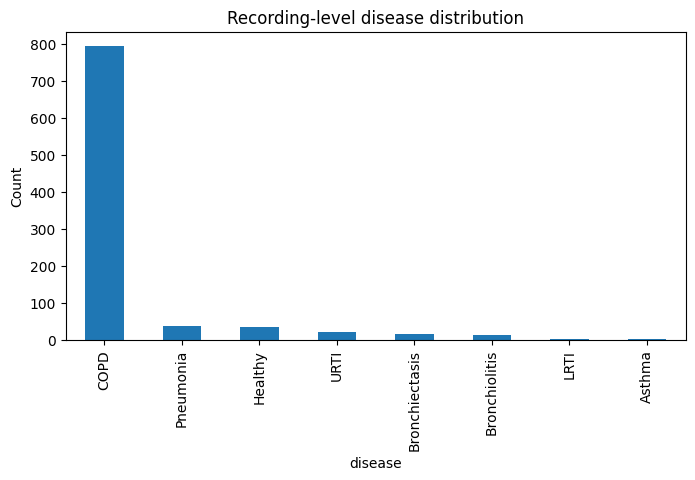

In [23]:
# Inspect disease distribution (recording-level)
disease_counts = df_base["disease"].value_counts()

print(disease_counts)

plt.figure(figsize=(8,4))
disease_counts.plot(kind="bar")
plt.title("Recording-level disease distribution")
plt.ylabel("Count")
plt.show()

In [24]:
df_base["disease"].value_counts()

disease
COPD              793
Pneumonia          37
Healthy            35
URTI               21
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

In [25]:
classes_to_remove = ["LRTI", "Asthma"]

df_base = df_base[~df_base["disease"].isin(classes_to_remove)]

df_base["disease"].value_counts()

disease
COPD              793
Pneumonia          37
Healthy            35
URTI               21
Bronchiectasis     16
Bronchiolitis      13
Name: count, dtype: int64

## Audio feature extraction

In [26]:
df = df_base.copy()

# empty list to store one row per recording
mfcc_features = []

for file_name in df["file_name"]:

    # create path
    file_path = os.path.join(audio_annot_path, file_name)

    # load audio waveform
    signal, sample_rate = librosa.load(file_path, sr=None)

    # calculate 13 MFCCs (13 = standard choice, start here)
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=13
    )

    # take mean, std, skew, max across time
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    mfcc_skew = skew(mfcc, axis=1)
    mfcc_max = np.max(mfcc, axis=1)

    # combine stats one feature vector
    combined_features = np.concatenate([
        mfcc_mean,
        mfcc_std,
        mfcc_skew,
        mfcc_max
    ])

    # store result
    mfcc_features.append([file_name] + list(combined_features))


In [27]:
# Update column names
columns =["file_name"]

for i in range(13):
    columns.append(f"mfcc_{i+1}_mean")

for i in range(13):
    columns.append(f"mfcc_{i+1}_std")

for i in range(13):
    columns.append(f"mfcc_{i+1}_skew")

for i in range(13):
    columns.append(f"mfcc_{i+1}_max")

mfcc_df = pd.DataFrame(mfcc_features, columns=columns)

mfcc_df.head()

,file_name,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,...,mfcc_4_max,mfcc_5_max,mfcc_6_max,mfcc_7_max,mfcc_8_max,mfcc_9_max,mfcc_10_max,mfcc_11_max,mfcc_12_max,mfcc_13_max
0,122_2b1_Tc_mc_LittC2SE.wav,-475.467804,99.900932,67.858276,37.558544,18.808765,9.815002,6.544002,7.426356,11.136246,...,62.235573,44.792793,39.420410,38.324738,33.560410,31.910103,30.660007,33.273952,36.951828,35.628494
1,113_1b1_Lr_sc_Litt3200.wav,-387.889313,152.080887,65.310318,21.508757,23.706589,36.867176,36.120018,23.505455,9.607650,...,58.201630,51.071724,59.805969,53.982986,46.037170,27.333187,24.094772,23.105511,21.731838,18.827480
2,178_1b3_Pl_mc_AKGC417L.wav,-374.355774,87.431442,55.022049,31.947367,22.166397,18.450672,16.308346,14.792700,13.485804,...,52.379166,39.588875,32.408669,30.264698,27.226286,24.085464,23.499599,23.879406,21.061861,19.930641
3,220_1b1_Tc_mc_LittC2SE.wav,-676.184692,153.194901,60.100471,41.074360,15.421990,8.430692,3.358740,6.331198,5.726296,...,58.522747,36.418633,33.469372,32.806286,30.109562,25.526587,22.443789,20.197735,18.931829,18.113634
4,176_1b3_Tc_mc_AKGC417L.wav,-307.473816,141.934540,60.927498,16.247877,15.853530,19.356161,19.289629,16.259007,7.465365,...,48.741539,45.765892,41.804680,44.209381,37.424446,28.089840,28.291445,25.865719,28.969883,18.460447


### Merge audio features with dataframe

In [28]:
df_audio = df.merge(mfcc_df, on="file_name", how="left")

df_audio.columns

Index(['file_name', 'patient_id', 'disease', 'age', 'sex', 'chest_location_Al',
       'chest_location_Ar', 'chest_location_Ll', 'chest_location_Lr',
       'chest_location_Pl', 'chest_location_Pr', 'chest_location_Tc', 'bmi',
       'has_crackles', 'has_wheezes', 'mfcc_1_mean', 'mfcc_2_mean',
       'mfcc_3_mean', 'mfcc_4_mean', 'mfcc_5_mean', 'mfcc_6_mean',
       'mfcc_7_mean', 'mfcc_8_mean', 'mfcc_9_mean', 'mfcc_10_mean',
       'mfcc_11_mean', 'mfcc_12_mean', 'mfcc_13_mean', 'mfcc_1_std',
       'mfcc_2_std', 'mfcc_3_std', 'mfcc_4_std', 'mfcc_5_std', 'mfcc_6_std',
       'mfcc_7_std', 'mfcc_8_std', 'mfcc_9_std', 'mfcc_10_std', 'mfcc_11_std',
       'mfcc_12_std', 'mfcc_13_std', 'mfcc_1_skew', 'mfcc_2_skew',
       'mfcc_3_skew', 'mfcc_4_skew', 'mfcc_5_skew', 'mfcc_6_skew',
       'mfcc_7_skew', 'mfcc_8_skew', 'mfcc_9_skew', 'mfcc_10_skew',
       'mfcc_11_skew', 'mfcc_12_skew', 'mfcc_13_skew', 'mfcc_1_max',
       'mfcc_2_max', 'mfcc_3_max', 'mfcc_4_max', 'mfcc_5_max', 'mfcc_6_max

In [29]:
df_audio.isna().sum()

file_name      0
patient_id     0
disease        0
age            0
sex            0
              ..
mfcc_9_max     0
mfcc_10_max    0
mfcc_11_max    0
mfcc_12_max    0
mfcc_13_max    0
Length: 67, dtype: int64

## Baseline Model

In [31]:
# ================================
# Define features and target
# ================================
X = df_audio.drop(columns=["disease", "file_name", "patient_id"])

y = df_audio["disease"]

# ================================
# Patient-Level Train/Test Split
# ================================
unique_patients = df_audio["patient_id"].unique()

# Split patients
train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    random_state=42
)

# Create boolean masks
train_mask = df_audio["patient_id"].isin(train_patients)
test_mask = df_audio["patient_id"].isin(test_patients)

# Apply masks
X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

X_train.shape[0], X_test.shape[0]


(765, 150)

In [33]:
# Check for overlaps in train/test data
set(df_audio.loc[train_mask, "patient_id"]) & set(df_audio.loc[test_mask, "patient_id"])

set()

In [34]:
# ================================
# Scale features
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# Train and fit Logistic Regression Model
# ================================
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

# ================================
# Evaluate
# ================================
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7866666666666666
                precision    recall  f1-score   support

Bronchiectasis       0.00      0.00      0.00         2
 Bronchiolitis       0.00      0.00      0.00         3
          COPD       0.92      0.96      0.94       114
       Healthy       0.30      0.38      0.33         8
     Pneumonia       0.71      0.29      0.42        17
          URTI       0.00      0.00      0.00         6

      accuracy                           0.79       150
     macro avg       0.32      0.27      0.28       150
  weighted avg       0.80      0.79      0.78       150



/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ 